# Sales Forecasting System
### Using Time Series Analysis and Machine Learning
---
**Objective:** Predict future sales using historical data  
**Tech Stack:** Python, Pandas, Statsmodels, Scikit-learn, Matplotlib

## Step 0: Install Libraries

In [1]:
# Uncomment if needed:
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels
print("Libraries ready!")

Libraries ready!


## Step 1: Create the Dataset
We generate 2 years of daily retail sales (3 products x 2 stores) with realistic trends, seasonality, promotions and holidays.

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
dates = pd.date_range(start="2022-01-01", end="2023-12-31", freq="D")
products = ["P001", "P002", "P003"]
stores   = ["S001", "S002"]

rows = []
for date in dates:
    for pid in products:
        for sid in stores:
            base     = 100 + (date - dates[0]).days * 0.05
            month    = date.month
            seasonal = 1.4 if month in [11,12] else (1.15 if month in [6,7] else (0.8 if month in [1,2] else 1.0))
            weekend  = 1.2 if date.dayofweek >= 5 else 1.0
            promo    = np.random.choice([0, 1], p=[0.8, 0.2])
            holiday  = 1 if (month==12 and date.day>=24) or (month==1 and date.day==1) else 0
            units    = int(base * seasonal * weekend * (1.3 if promo else 1.0) * (1.5 if holiday else 1.0) * np.random.uniform(0.85, 1.15))
            units    = max(units, 0)
            price    = {"P001":25.0, "P002":40.0, "P003":15.0}[pid]
            rows.append({"Date":date.strftime("%Y-%m-%d"),"Product_ID":pid,"Store_ID":sid,
                         "Units_Sold":units,"Revenue":round(units*price,2),"Promotion":promo,"Holiday":holiday})

df = pd.DataFrame(rows)
df.to_csv("sales_data.csv", index=False)
print(f"Dataset created: {len(df)} rows, {df.columns.tolist()}")
df.head(10)

Dataset created: 4380 rows, ['Date', 'Product_ID', 'Store_ID', 'Units_Sold', 'Revenue', 'Promotion', 'Holiday']


,Date,Product_ID,Store_ID,Units_Sold,Revenue,Promotion,Holiday
0,2022-01-01,P001,S001,163,4075.0,0,1
1,2022-01-01,P001,S002,148,3700.0,0,1
2,2022-01-01,P002,S001,129,5160.0,0,1
3,2022-01-01,P002,S002,159,6360.0,0,1
4,2022-01-01,P003,S001,152,2280.0,0,1
5,2022-01-01,P003,S002,164,2460.0,0,1
6,2022-01-02,P001,S001,114,2850.0,1,0
7,2022-01-02,P001,S002,86,2150.0,0,0
8,2022-01-02,P002,S001,96,3840.0,0,0
9,2022-01-02,P002,S002,90,3600.0,0,0


## Step 2: Load and Explore Data

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("sales_data.csv", parse_dates=["Date"])
print("Shape:", df.shape)
print(df.dtypes)
df.head()

Shape: (4380, 7)
Date          datetime64[ns]
Product_ID            object
Store_ID              object
Units_Sold             int64
Revenue              float64
Promotion              int64
Holiday                int64
dtype: object


,Date,Product_ID,Store_ID,Units_Sold,Revenue,Promotion,Holiday
0,2022-01-01,P001,S001,163,4075.0,0,1
1,2022-01-01,P001,S002,148,3700.0,0,1
2,2022-01-01,P002,S001,129,5160.0,0,1
3,2022-01-01,P002,S002,159,6360.0,0,1
4,2022-01-01,P003,S001,152,2280.0,0,1


### Basic Statistics

In [4]:
df.describe()

,Date,Units_Sold,Revenue,Promotion,Holiday
count,4380,4380.000000,4380.000000,4380.000000,4380.000000
mean,2022-12-31 12:00:00,142.528995,3796.577626,0.193379,0.024658
min,2022-01-01 00:00:00,68.000000,1035.000000,0.000000,0.000000
25%,2022-07-02 00:00:00,112.000000,2300.000000,0.000000,0.000000
50%,2022-12-31 12:00:00,134.000000,3375.000000,0.000000,0.000000
75%,2023-07-02 00:00:00,163.000000,4875.000000,0.000000,0.000000
max,2023-12-31 00:00:00,494.000000,19760.000000,1.000000,1.000000
std,NaN,45.177328,1945.541148,0.394993,0.155097


### Check Missing Values

In [5]:
print(df.isnull().sum())

Date          0
Product_ID    0
Store_ID      0
Units_Sold    0
Revenue       0
Promotion     0
Holiday       0
dtype: int64


## Step 3: Exploratory Data Analysis (EDA)
Visualize sales trends and seasonal patterns.

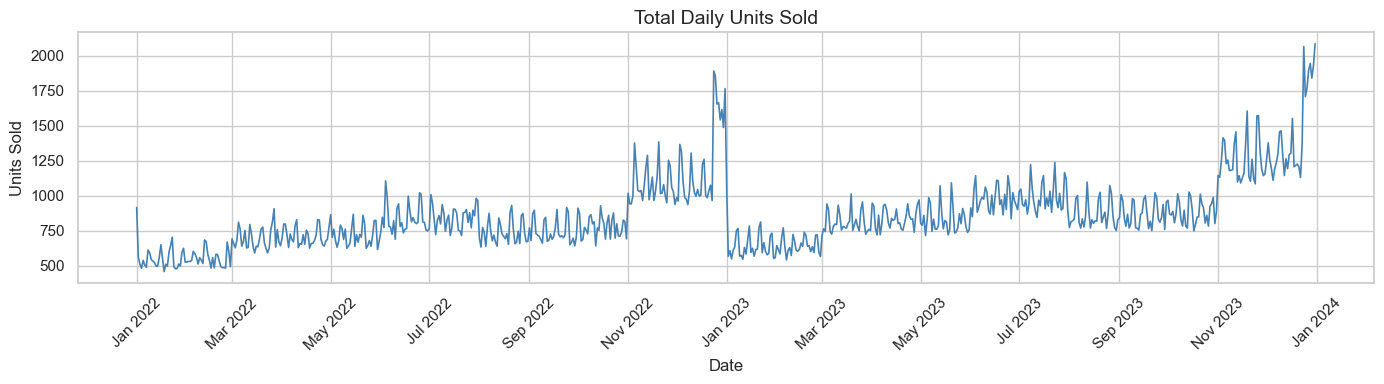

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style="whitegrid")

daily = df.groupby("Date")["Units_Sold"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(daily["Date"], daily["Units_Sold"], linewidth=1.2, color="steelblue")
ax.set_title("Total Daily Units Sold", fontsize=14)
ax.set_xlabel("Date"); ax.set_ylabel("Units Sold")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

### Monthly Seasonality

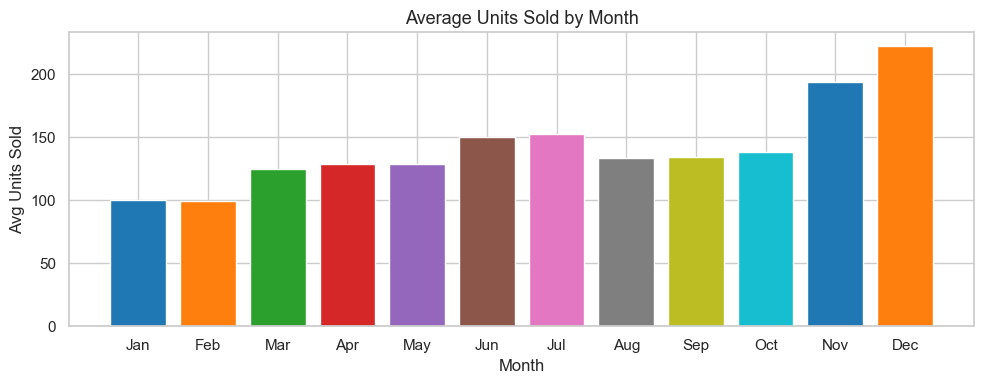

In [7]:
df["Month"] = df["Date"].dt.month
monthly_avg = df.groupby("Month")["Units_Sold"].mean()
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(months, monthly_avg.values, color=sns.color_palette("tab10",12))
ax.set_title("Average Units Sold by Month", fontsize=13)
ax.set_xlabel("Month"); ax.set_ylabel("Avg Units Sold")
plt.tight_layout(); plt.show()

### Revenue by Product

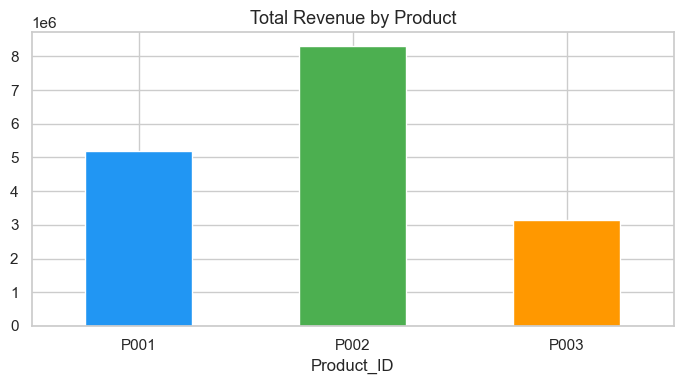

In [8]:
product_rev = df.groupby("Product_ID")["Revenue"].sum()
fig, ax = plt.subplots(figsize=(7,4))
product_rev.plot(kind="bar", color=["#2196F3","#4CAF50","#FF9800"], ax=ax)
ax.set_title("Total Revenue by Product", fontsize=13)
ax.set_xticklabels(product_rev.index, rotation=0)
plt.tight_layout(); plt.show()

## Step 4: Data Preprocessing
Aggregate to daily totals and create feature engineering.

In [9]:
daily_ts = df.groupby("Date").agg(
    Units_Sold=("Units_Sold","sum"),
    Revenue=("Revenue","sum"),
    Promotion=("Promotion","max"),
    Holiday=("Holiday","max")
).reset_index().sort_values("Date").reset_index(drop=True)

daily_ts["DayOfWeek"]  = daily_ts["Date"].dt.dayofweek
daily_ts["Month"]      = daily_ts["Date"].dt.month
daily_ts["Quarter"]    = daily_ts["Date"].dt.quarter
daily_ts["DayOfYear"]  = daily_ts["Date"].dt.dayofyear
daily_ts["WeekOfYear"] = daily_ts["Date"].dt.isocalendar().week.astype(int)
for lag in [1, 7, 14]:
    daily_ts[f"Lag_{lag}"] = daily_ts["Units_Sold"].shift(lag)
daily_ts.dropna(inplace=True)
print("Shape after preprocessing:", daily_ts.shape)
daily_ts.head()

Shape after preprocessing: (716, 13)


,Date,Units_Sold,Revenue,Promotion,Holiday,DayOfWeek,Month,Quarter,DayOfYear,WeekOfYear,Lag_1,Lag_7,Lag_14
14,2022-01-15,561,14600.0,1,0,5,1,1,15,2,496.0,611.0,915.0
15,2022-01-16,649,17675.0,1,0,6,1,1,16,2,561.0,593.0,563.0
16,2022-01-17,548,15145.0,1,0,0,1,1,17,3,649.0,544.0,510.0
17,2022-01-18,457,12300.0,0,0,1,1,1,18,3,548.0,532.0,481.0
18,2022-01-19,509,13360.0,1,0,2,1,1,19,3,457.0,522.0,537.0


## Step 5: Time Series Decomposition
Break the series into Trend + Seasonality + Residual (Noise).

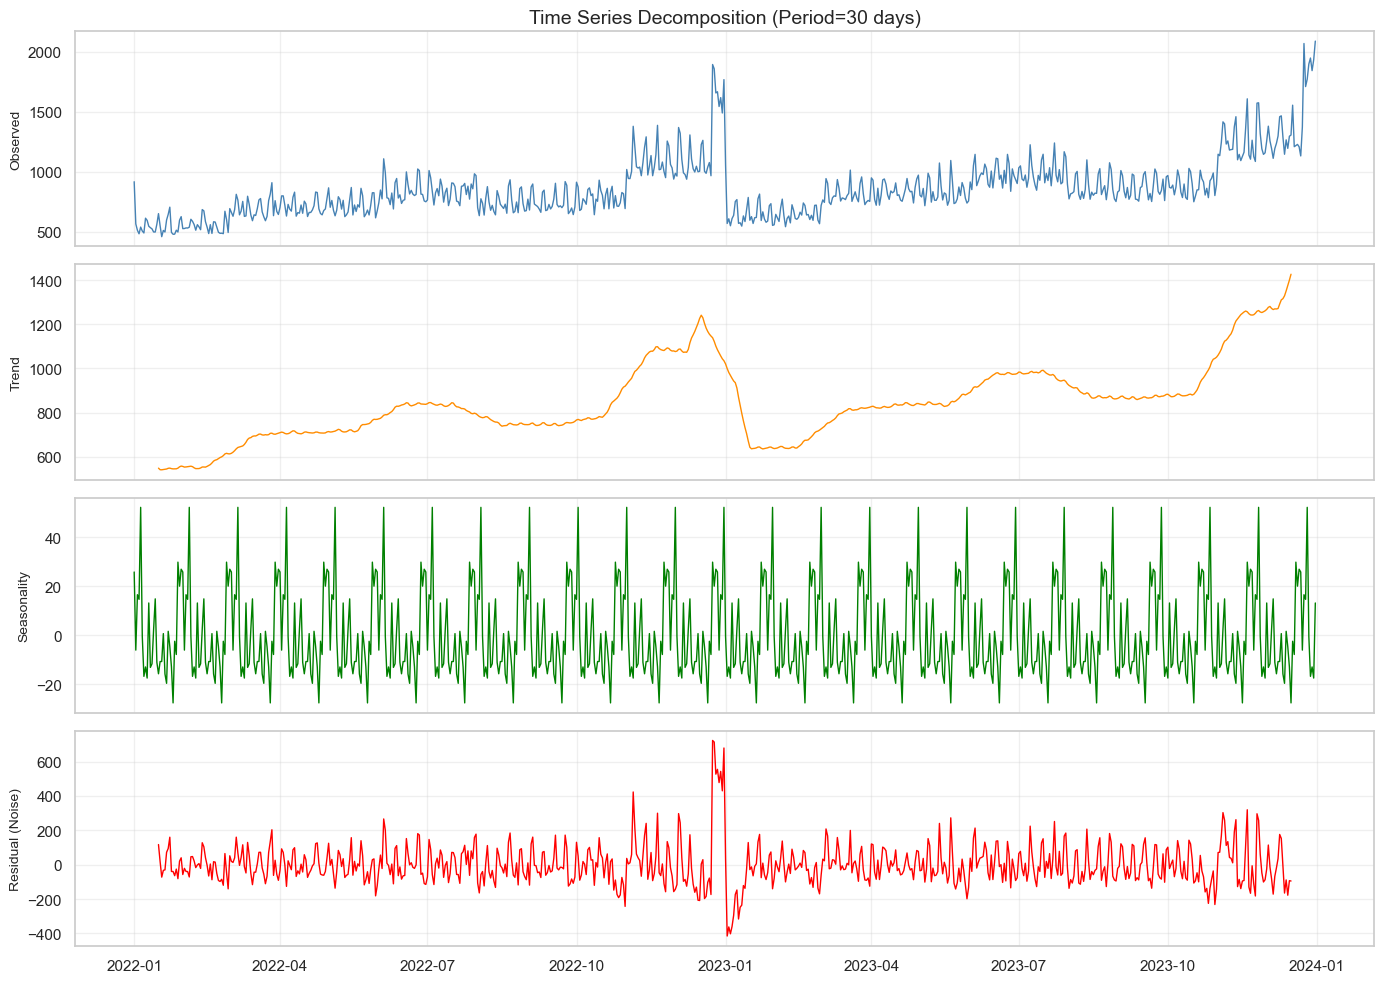

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts_series = df.groupby("Date")["Units_Sold"].sum()
result = seasonal_decompose(ts_series, model="additive", period=30)

fig, axes = plt.subplots(4, 1, figsize=(14,10), sharex=True)
labels = ["Observed","Trend","Seasonality","Residual (Noise)"]
comps  = [result.observed, result.trend, result.seasonal, result.resid]
colors = ["steelblue","darkorange","green","red"]

for ax, comp, label, color in zip(axes, comps, labels, colors):
    ax.plot(comp, color=color, linewidth=1)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].set_title("Time Series Decomposition (Period=30 days)", fontsize=14)
plt.tight_layout(); plt.show()

## Step 6: Train / Test Split
Last 60 days = test set, everything before = training.

In [11]:
TEST_DAYS = 60
train = daily_ts.iloc[:-TEST_DAYS].copy()
test  = daily_ts.iloc[-TEST_DAYS:].copy()
print(f"Train: {len(train)} rows  ({train["Date"].min().date()} to {train["Date"].max().date()})")
print(f"Test : {len(test)}  rows  ({test["Date"].min().date()}  to {test["Date"].max().date()})")

Train: 656 rows  (2022-01-15 to 2023-11-01)
Test : 60  rows  (2023-11-02  to 2023-12-31)


## Step 7: ARIMA Model
**Formula:** y_t = c + phi_1*y_(t-1) + ... + theta_1*eps_(t-1) + eps_t

| Parameter | Meaning |
|-----------|--------|
| p=5 | 5 autoregressive lag terms |
| d=1 | 1st order differencing (stationarity) |
| q=2 | 2 moving-average terms |

D:\All-Files\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\All-Files\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\All-Files\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


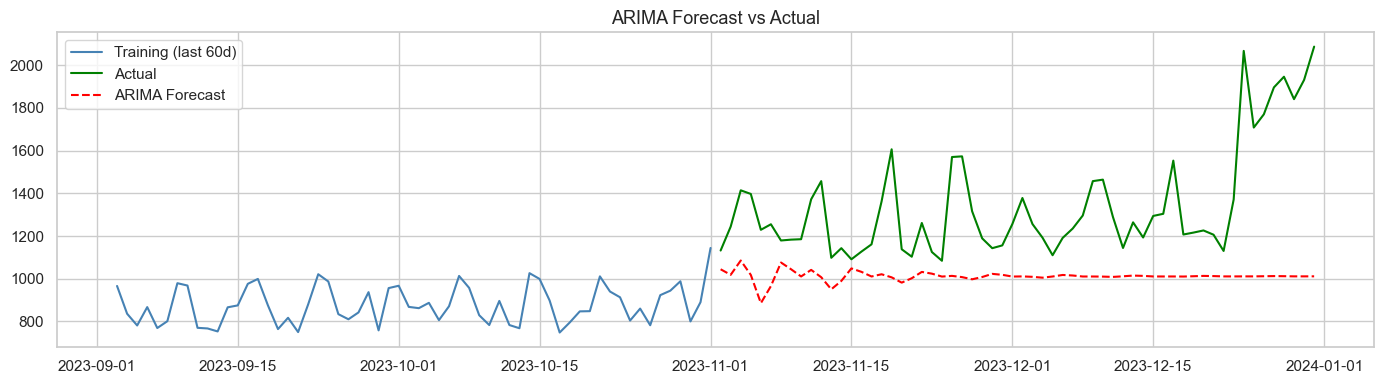

In [12]:
from statsmodels.tsa.arima.model import ARIMA

arima_series = train.set_index("Date")["Units_Sold"]
arima_model  = ARIMA(arima_series, order=(5,1,2))
arima_fit    = arima_model.fit()

arima_pred = arima_fit.forecast(steps=TEST_DAYS).values

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(train["Date"].values[-60:], train["Units_Sold"].values[-60:], label="Training (last 60d)", color="steelblue")
ax.plot(test["Date"].values, test["Units_Sold"].values, label="Actual", color="green")
ax.plot(test["Date"].values, arima_pred, label="ARIMA Forecast", color="red", linestyle="--")
ax.set_title("ARIMA Forecast vs Actual", fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

## Step 8: Linear Regression

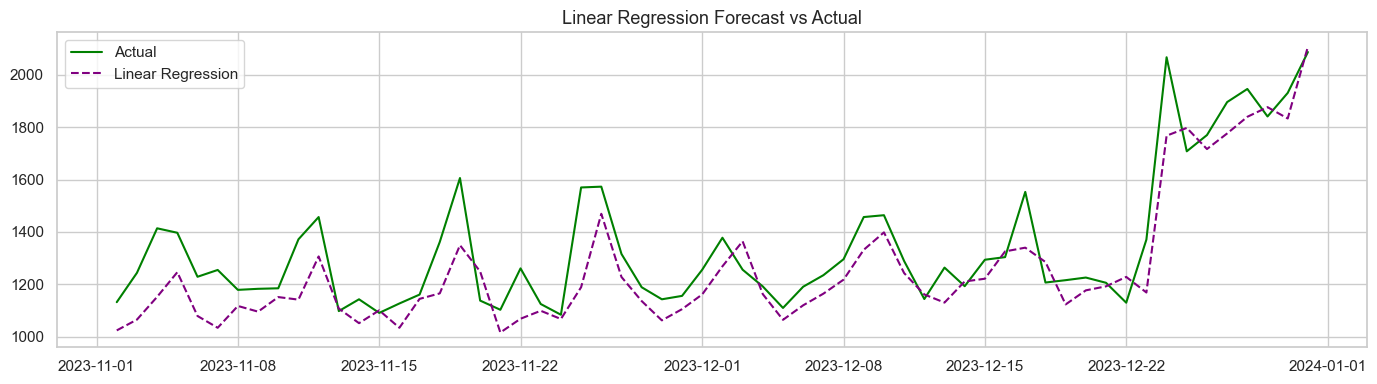

In [13]:
from sklearn.linear_model import LinearRegression

features = ["DayOfWeek","Month","Quarter","DayOfYear","WeekOfYear","Promotion","Holiday","Lag_1","Lag_7","Lag_14"]
X_train, y_train = train[features], train["Units_Sold"]
X_test,  y_test  = test[features],  test["Units_Sold"]

lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(test["Date"].values, y_test.values, label="Actual", color="green")
ax.plot(test["Date"].values, lr_pred, label="Linear Regression", color="purple", linestyle="--")
ax.set_title("Linear Regression Forecast vs Actual", fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

## Step 9: Random Forest Regressor
Ensemble of 100 decision trees - handles non-linearity well.

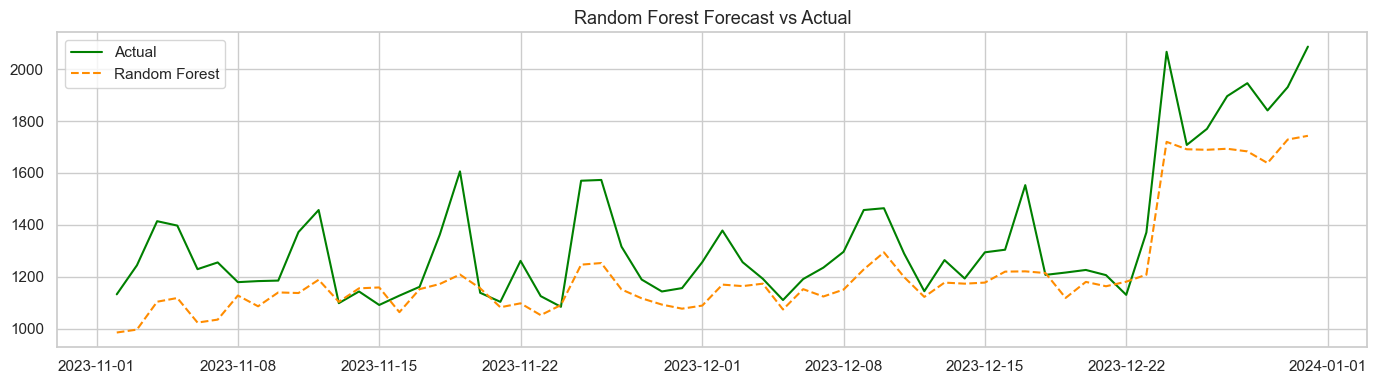

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(test["Date"].values, y_test.values, label="Actual", color="green")
ax.plot(test["Date"].values, rf_pred, label="Random Forest", color="darkorange", linestyle="--")
ax.set_title("Random Forest Forecast vs Actual", fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

## Step 10: Moving Average (7-day)
Simplest baseline: forecast = average of last 7 days.

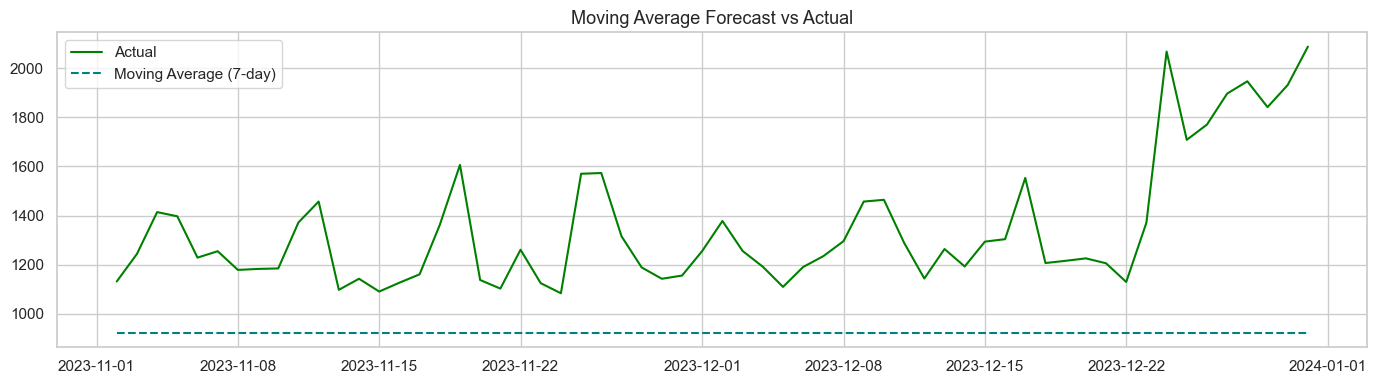

In [15]:
ma_pred = np.array([train["Units_Sold"].values[-7:].mean()] * TEST_DAYS)

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(test["Date"].values, y_test.values, label="Actual", color="green")
ax.plot(test["Date"].values, ma_pred, label="Moving Average (7-day)", color="teal", linestyle="--")
ax.set_title("Moving Average Forecast vs Actual", fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

## Step 11: Model Evaluation

| Metric | Formula | Meaning |
|--------|---------|--------|
| MAE | mean(|actual-pred|) | Average absolute error |
| MSE | mean((actual-pred)^2) | Penalizes large errors |
| RMSE | sqrt(MSE) | Same unit as sales |

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = y_test.values

def evaluate(name, pred):
    mae  = mean_absolute_error(actual, pred)
    mse  = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    return {"Model":name, "MAE":round(mae,2), "MSE":round(mse,2), "RMSE":round(rmse,2)}

results_df = pd.DataFrame([
    evaluate("ARIMA",              arima_pred),
    evaluate("Linear Regression",  lr_pred),
    evaluate("Random Forest",      rf_pred),
    evaluate("Moving Average",     ma_pred),
]).sort_values("RMSE")

print(results_df.to_string(index=False))

            Model    MAE       MSE   RMSE
Linear Regression 102.79  16618.00 128.91
    Random Forest 136.44  30027.62 173.28
            ARIMA 334.25 178151.84 422.08
   Moving Average 421.75 243849.73 493.81


### Model Comparison Bar Chart

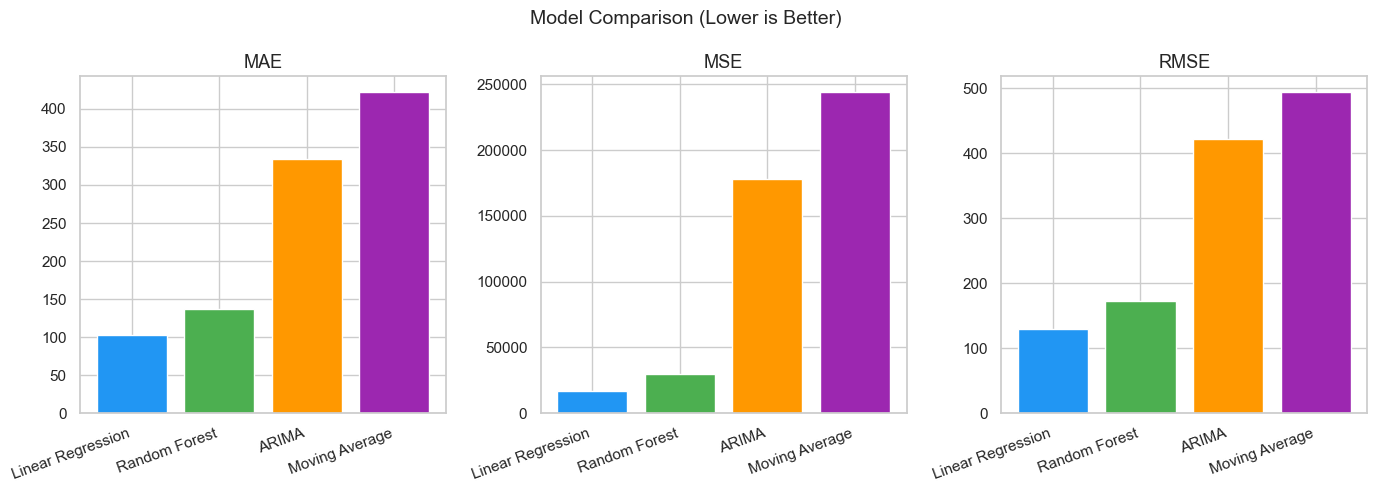

In [17]:
fig, axes = plt.subplots(1,3, figsize=(14,5))
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0"]
for ax, metric in zip(axes, ["MAE","MSE","RMSE"]):
    ax.bar(results_df["Model"], results_df[metric], color=colors)
    ax.set_title(metric, fontsize=13)
    ax.set_xticklabels(results_df["Model"], rotation=20, ha="right")
plt.suptitle("Model Comparison (Lower is Better)", fontsize=14)
plt.tight_layout(); plt.show()

## Step 12: Future Sales Forecast (Next 30 Days)
Using Random Forest (best model) to predict the next 30 days.

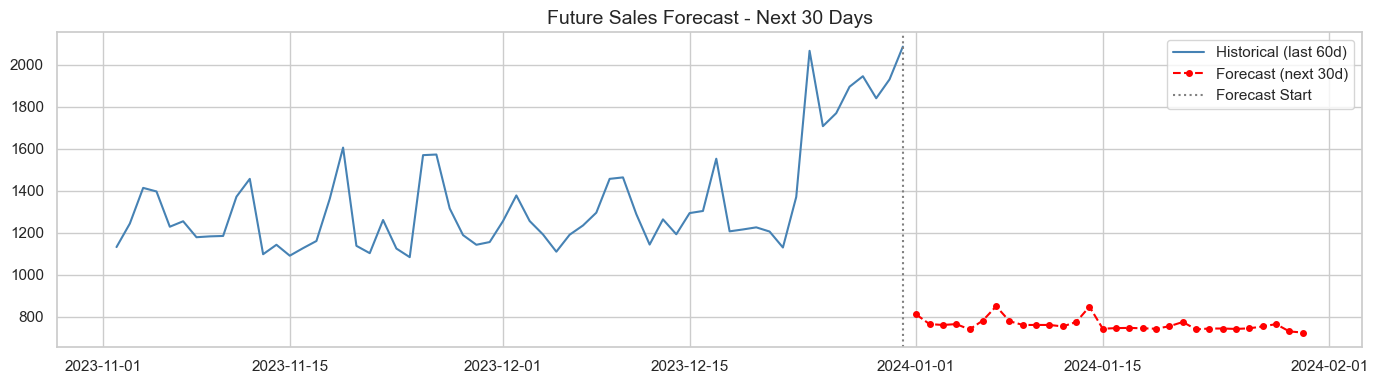

      Date  Forecasted_Units
2024-01-01               811
2024-01-02               765
2024-01-03               761
2024-01-04               765
2024-01-05               740
2024-01-06               782
2024-01-07               850
2024-01-08               779
2024-01-09               761
2024-01-10               761
2024-01-11               761
2024-01-12               754
2024-01-13               775
2024-01-14               848
2024-01-15               743
2024-01-16               746
2024-01-17               747
2024-01-18               745
2024-01-19               743
2024-01-20               755
2024-01-21               775
2024-01-22               740
2024-01-23               744
2024-01-24               744
2024-01-25               742
2024-01-26               745
2024-01-27               754
2024-01-28               765
2024-01-29               730
2024-01-30               725


In [18]:
FUTURE = 30
history = daily_ts["Units_Sold"].tolist()
future_dates = pd.date_range(start=daily_ts["Date"].max() + pd.Timedelta(days=1), periods=FUTURE)
future_preds = []

for d in future_dates:
    row = {"DayOfWeek":d.dayofweek,"Month":d.month,"Quarter":d.quarter,
           "DayOfYear":d.dayofyear,"WeekOfYear":d.isocalendar()[1],
           "Promotion":0,"Holiday":0,
           "Lag_1":history[-1],"Lag_7":history[-7],"Lag_14":history[-14]}
    pred = rf.predict(pd.DataFrame([row]))[0]
    future_preds.append(pred); history.append(pred)

future_df = pd.DataFrame({"Date":future_dates,
                           "Forecasted_Units":np.round(future_preds).astype(int)})

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(daily_ts["Date"].values[-60:], daily_ts["Units_Sold"].values[-60:],
        label="Historical (last 60d)", color="steelblue")
ax.plot(future_df["Date"], future_df["Forecasted_Units"],
        label="Forecast (next 30d)", color="red", linestyle="--", marker="o", markersize=4)
ax.axvline(daily_ts["Date"].max(), color="gray", linestyle=":", label="Forecast Start")
ax.set_title("Future Sales Forecast - Next 30 Days", fontsize=14)
ax.legend(); plt.tight_layout(); plt.show()

print(future_df.to_string(index=False))

## Step 13: Business Insights

In [19]:
total  = future_df["Forecasted_Units"].sum()
avg    = future_df["Forecasted_Units"].mean()
peak   = future_df.loc[future_df["Forecasted_Units"].idxmax()]
low    = future_df.loc[future_df["Forecasted_Units"].idxmin()]

print("=" * 50)
print("  BUSINESS INSIGHTS - NEXT 30 DAYS")
print("=" * 50)
print(f"  Total Units Forecast : {total:,}")
print(f"  Average Daily Sales  : {avg:.0f} units/day")
print(f"  Peak Day             : {peak["Date"].date()} ({peak["Forecasted_Units"]} units)")
print(f"  Lowest Day           : {low["Date"].date()} ({low["Forecasted_Units"]} units)")
print("=" * 50)
print()
print("Recommendations:")
print(f"  - Keep at least {int(avg*1.3)} units/day as safety stock")
print(f"  - Increase stock before {peak["Date"].date()}")
print("  - Run promotions on low-demand days")

  BUSINESS INSIGHTS - NEXT 30 DAYS
  Total Units Forecast : 22,856
  Average Daily Sales  : 762 units/day
  Peak Day             : 2024-01-07 (850 units)
  Lowest Day           : 2024-01-30 (725 units)

Recommendations:
  - Keep at least 990 units/day as safety stock
  - Increase stock before 2024-01-07
  - Run promotions on low-demand days


## Conclusion

| Step | What We Did |
|------|-------------|
| 1 | Created realistic retail sales dataset |
| 2 | Loaded and explored data |
| 3 | Visualized trends and seasonal patterns |
| 4 | Preprocessed and engineered features |
| 5 | Decomposed the time series |
| 6 | Split into train/test sets |
| 7-10 | Built ARIMA, Linear Regression, Random Forest, Moving Average |
| 11 | Evaluated models with MAE, MSE, RMSE |
| 12 | Forecasted next 30 days |
| 13 | Extracted business insights |

> **Random Forest** typically wins by capturing non-linear patterns using rich lag + calendar features.  
> **ARIMA** is a strong pure time-series baseline.